# Applying Galactic $\gamma\gamma$ Attenuation to an Extended Source Spectrum

This tutorial demonstrates how to model Galactic $\gamma\gamma$ absorption for an extended gamma-ray source using the GPSP atlas.

The example is based on the Galactic Center diffuse PeVatron emission region observed by H.E.S.S.

**Acceleration of petaelectronvolt protons in the Galactic Centre, https://arxiv.org/abs/1603.07730**

Topics covered in this tutorial:

- Defining an extended source morphology
- Sampling source extent and distance uncertainties
- Computing region-averaged survival probability profiles
- Inspecting morphology and uncertainty propagation
- Applying attenuation to intrinsic gamma-ray emission models from hadronic pp interactions

The same workflow can be applied to any Galactic gamma-ray source for which the position, morphology, and distance are known.

In [1]:
import os
import sys

# Do not forget to edit here!
sys.path.insert(0, os.path.abspath("../../../gpsp-atlas"))

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import QTable
from matplotlib.patches import Wedge
from matplotlib.lines import Line2D
from gammapy.estimators import FluxPoints
from gpsp_atlas_helper import GPSPAtlasHelper

In [2]:
# Configuration for plots
STYLE = {
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 18,
    "axes.labelweight": "normal",
    "axes.titleweight": "normal",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "figure.titlesize": 20,
    "font.weight": "normal"
}
plt.rcParams.update(STYLE)

# Load Atlas
atlas_r12 = GPSPAtlasHelper("GPSP_Atlas_R12.fits")

## Defining the Source Region

The GPSP helper can compute survival probability profiles for:

- `point` sources (angular extent up to 0.1$^{\circ}$)
- `box` regions
- `extended` regions

In this example, the Galactic Center PeVatron diffuse emission is approximated as an extended annuli region defined in the publication (see Fig.1 right in the H.E.S.S. paper).

The source morphology, distance, sampling strategy, and uncertainty treatment are configured below.

In [3]:
#Define target here
target_l = 0.0
target_b = 0.0
target_d = 8.5 #kpc
target_d_err = 0.2 # kpc

# Define shape here. 
# One can choose 'point', 'box' or 'extended'. 
# See API reference for details.
shape = 'extended' 
r_in = 0.15 #deg
r_out = 0.45 #deg
phi_start = 10.0
phi_stop = 304.0

# Define weighting here
n_points = 100 # Number of points to sample the chosen shape
# One can choose 'flat', 'gaussian' for weighting method
weighting = 'flat' 
# Distributes sample points in equal areas, other options are 'uniform_radius', 'center_enhanced'
radial_sampling='equal_area' 
# Method for confidence intervals: 'percentile' or 'minmax'
average_mode = 'percentile'
percentile=68 # This is 1 Sigma
include_distance_uncertainty = True # False for getting errors only on morphology sampling
distance_sampling = 'mc' # Use Monte Carlo simulations for distance sampling. Other option is 'grid'
n_distance_samples = 500 # Number of distance samples
distance_sigma_clip=3.0 # Exclude MC distance values beyond 3.0 sigma
seed = 1
return_individual = True # Returns all survival profiles as array

# kwargs for extracting survival profiles for the emission region from the GPSP atlas
region_kwargs = dict(l=target_l, b=target_b, d=8.5, d_err=0.2, 
                     shape=shape, r_in=r_in, r_out=r_out, phi_start=phi_start, phi_stop=phi_stop, n_points=n_points, 
                     weighting=weighting, radial_sampling=radial_sampling, average_mode=average_mode, percentile=percentile, 
                     include_distance_uncertainty=include_distance_uncertainty, 
                     distance_sampling=distance_sampling, n_distance_samples=n_distance_samples, 
                     distance_sigma_clip=distance_sigma_clip, random_seed=seed, return_individual=return_individual)

## Region-Averaged Survival Profiles

The `get_region_survival_profile()` function computes a survival probability profile averaged over the selected source morphology and distance distribution (defined as **region_kwargs** above).

The returned object is a Python dictionary containing the following quantities:

| Key | Description |
|------|-------------|
| `energies_ev` | GPSP energy grid |
| `average` | Region-averaged survival profile |
| `low` | Lower confidence envelope |
| `high` | Upper confidence envelope |
| `points` | Spatial sampling locations |
| `weights` | Weights assigned to sampling locations |
| `distance_samples` | Sampled source distances |
| `distance_weights` | Weights assigned to distance samples |
| `profiles` | Individual survival profiles |
| `profile_weights` | Weights assigned to individual profiles |

For the configuration defined above:

- 100 spatial sampling points are generated within the selected source morphology.
- 500 distance realizations are generated through Monte Carlo sampling.
- A total of 50,000 survival profiles (100$\times$500) are evaluated.
- The confidence interval corresponds to the selected 68% percentile range.

The returned survival profile can subsequently be used for attenuation corrections, spectral reconstruction, or uncertainty propagation studies.

In [4]:
# Get the python dictionary containing results
result_r12 = atlas_r12.get_region_survival_profile(**region_kwargs)

## Visualizing Morphological Sampling

The GPSP helper evaluates the source morphology by generating a set of sampling points inside the selected region.

For extended sources, three radial sampling schemes are available:

### `equal_area`

Provides approximately uniform area coverage within the selected region. This is generally the recommended option for extended diffuse source analyses.

### `uniform_radius`

Uses uniformly spaced radii between `r_in` and `r_out`.

### `center_enhanced`

Concentrates sampling points toward the source center according to a user-defined `center_density_power` parameter.

This option may be useful when the intrinsic source brightness is expected to peak strongly toward the center.

The figure below shows the spatial sampling generated for the Galactic Center diffuse emission region using the `equal_area` method.

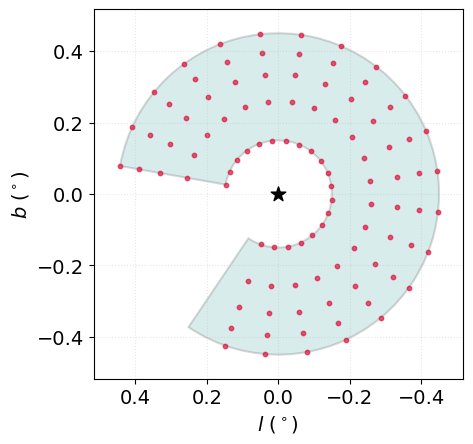

In [5]:
fig, ax = plt.subplots()

# Reconstruct the region of interest (ROI) as defined in region_kwargs
roi_wedge = Wedge(center=(0, 0), r=region_kwargs['r_out'], 
                  theta1=region_kwargs['phi_start'], theta2=region_kwargs['phi_stop'],
                  width=region_kwargs['r_out'] - region_kwargs['r_in'],
                  facecolor='teal', alpha=0.15, edgecolor='black', lw=1.5)

ax.add_patch(roi_wedge)
# Ensure that the returned figure is a box
ax.set_aspect('equal', adjustable='box')
# Distribute the sample points generated by get_region_survival_profile()
ax.scatter(result_r12["points"][:, 0], result_r12["points"][:, 1], color='crimson', s=10, alpha=0.7)

ax.scatter(0.0, 0.0, marker='*', s=120, color='black', zorder=5, label='Sgr A*')
ax.set_xlabel(r"$l$ ($^\circ$)")
ax.set_ylabel(r"$b$ ($^\circ
# Invert x-axis to get the identical configuration shown in the paper
ax.invert_xaxis()
# Make some space in the figure
lim = region_kwargs['r_out'] * 1.15
ax.set_xlim(lim, -lim)
ax.set_ylim(-lim, lim)
ax.grid(alpha=0.3, ls=':')

## Survival Probability Ensemble

The uncertainty band associated with the survival probability profile is derived from the full ensemble of survival profiles generated (for this case, 50,000 profiles) during the analysis.

Each profile corresponds to a particular realization of:

- source morphology sampling,
- distance sampling,
- weighting scheme.

The gray curves below show all individual survival profiles, while the colored band corresponds to the selected confidence interval.

For this example, the band represents the central 68% confidence region obtained from all 50,000 realizations.

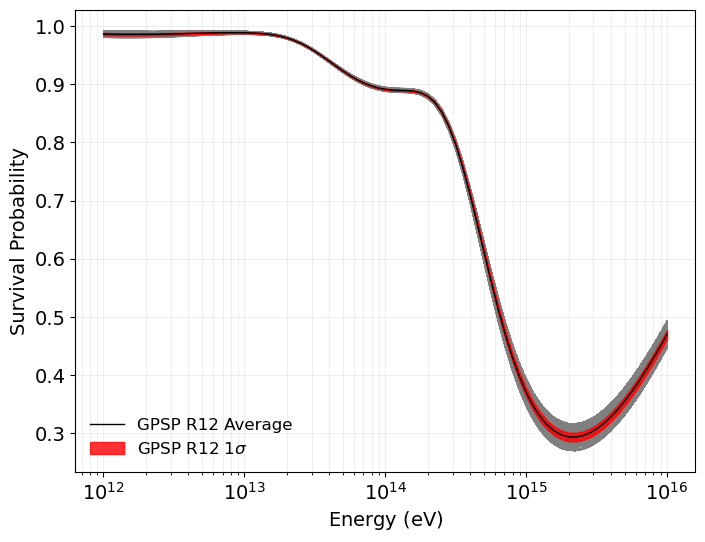

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

# Loop through each profile manually to plot them on top of each other. 
# This will plot 50,000 profiles
for i in range(len(result_r12['profiles'])):
    ax.plot(result_r12['energies_ev'], result_r12['profiles'][i], color='gray', alpha=0.1,lw=0.5)

# This is the average of 50,000 profiles
ax.plot(result_r12["energies_ev"], result_r12["average"], color='black', lw=1.0, label='GPSP R12 Average', zorder=11)

# This is the band between min and max (68 percentile, 1 sigma in this case)
ax.fill_between(result_r12["energies_ev"], result_r12["low"], result_r12["high"], color='red', alpha=0.8,zorder=10, label='GPSP R12 1$\sigma$')
ax.set_xscale('log')
ax.set_xlabel('Energy ($\mathrm{eV}$)')
ax.set_ylabel('Survival Probability')
ax.legend(loc='lower left', frameon=False)
ax.grid(alpha=0.2, which='both')

## Distribution of Survival Probabilities

At a fixed energy, the ensemble of survival profiles produces a distribution of possible survival probability values.

This distribution reflects the combined uncertainty associated with:

- source morphology,
- source distance,
- adopted sampling strategy.

The histogram below illustrates the distribution of survival probabilities at 2 PeV.

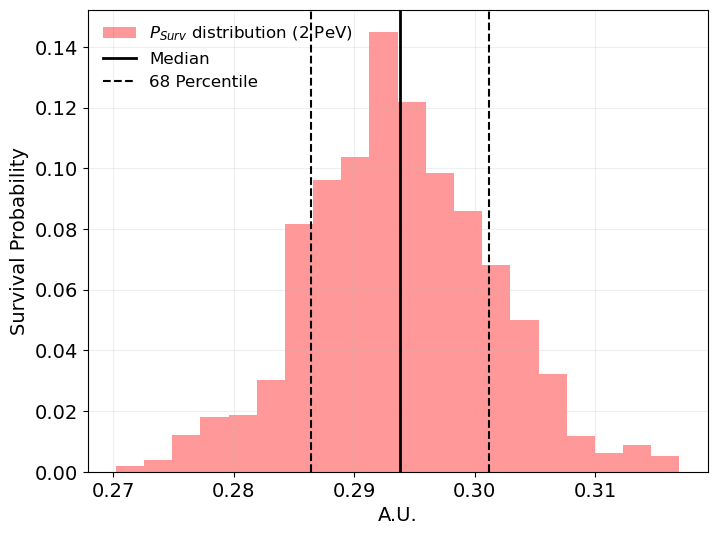

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

# Lets check the distribution at 2 PeV
target_energy_distribution = 2.0e15  

e_idx = np.argmin(np.abs(result_r12["energies_ev"] - target_energy_distribution))

# Make a histogram of survival probabilities at 2 PeV bin. Note that profile_weights are flat here since we chose weighting = 'flat').
ax.hist(result_r12["profiles"][:, e_idx], bins=20, weights=result_r12["profile_weights"], alpha=0.4, color='red', label='$P_{Surv}$ distribution (2 PeV)')

ax.axvline(result_r12["average"][e_idx], color='black', lw=2.0, label='Median')
ax.axvline(result_r12["low"][e_idx], color='black', ls='--', lw=1.5, label='68 Percentile')
ax.axvline(result_r12["high"][e_idx], color='black', ls='--', lw=1.5)
ax.set_xlabel('A.U.')
ax.set_ylabel('Survival Probability')
ax.legend(loc='upper left', frameon=False)
ax.grid(alpha=0.2, which='both')

## Distance Sampling

Distance uncertainties can be incorporated directly into the survival probability calculation.

For this example, the source distance is assumed to be

$d = 8.5\ \mathrm{kpc}$

with an uncertainty of

$\sigma_d = 0.2\ \mathrm{kpc}$.

Distance realizations are generated through Monte Carlo sampling assuming a Gaussian distribution.

The histogram below shows the resulting distribution of sampled distances used in the survival profile calculation.

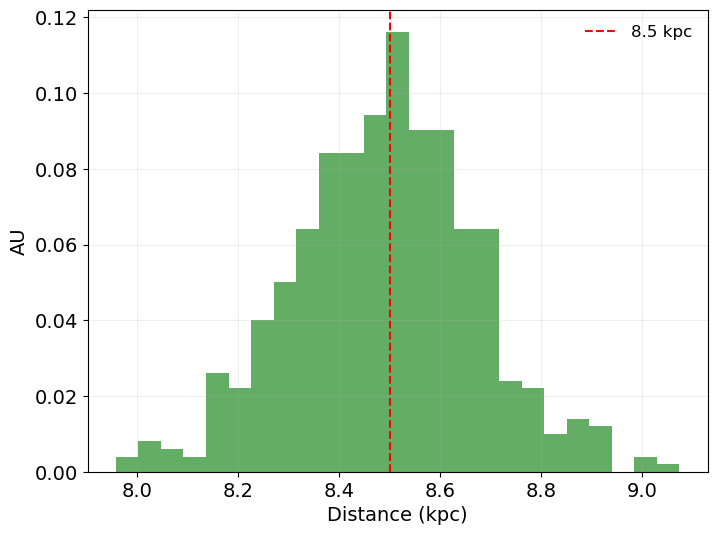

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(result_r12["distance_samples"], bins=25, weights=result_r12["distance_weights"], alpha=0.7, color='forestgreen')
ax.axvline(region_kwargs["d"], color='red', lw=1.5, ls='--', label='8.5 kpc')
ax.set_xlabel("Distance (kpc)")
ax.set_ylabel("AU")
ax.legend(loc='upper right', frameon=False)
ax.grid(alpha=0.2)

## Applying Attenuation to Intrinsic Gamma-Ray Spectra

The GPSP atlas can be used to predict the observed spectrum after attenuation from an intrinsic gamma-ray emission model.

In this example, intrinsic spectra produced through hadronic proton-proton interactions are used as input models. Several proton cutoff energies ($E_{p,cut}=3$ PeV, $E_{p,cut}=10$ PeV and $E_{p,cut}=30$ PeV) are considered in order to illustrate the effect of Galactic $\gamma\gamma$ attenuation on the resulting gamma-ray spectrum.

The model templates used in this tutorial are available in the **Example Data** section of the documentation.

The goal is to calculate the attenuated spectrum expected at Earth. 

One can further compare the prediction with the sensitivity curves of future experiments (i.e. CTA or SWGO).

In [9]:
# Read gamma-ray model files form hadronic pp interactions
base_dir = "example_datasets" # You can find the files below under "Example Datasets" section
models = [
    {"cutoff": 3,  "file": base_dir + "gc_pp_model_3PeV.ecsv"},
    {"cutoff": 10, "file": base_dir + "gc_pp_model_10PeV.ecsv"},
    {"cutoff": 30, "file": base_dir + "gc_pp_model_30PeV.ecsv"}
]

# Read the H.E.S.S. flux points data directly into a QTable
hess_flux_data = 'example_datasets/gc_pacman_hess.dat'
table = QTable.read(hess_flux_data, format='ascii.ecsv')

# Keep the quantities (values + units) intact
hess_energy = table['e_ref']
hess_dnde = table['dnde']
hess_dnde_err = table['dnde_err']

# Scaling with energy_power=2 handles the units automatically (1 / (cm2 s TeV) --> TeV / (cm2 s)) to get SED.
hess_sed = hess_dnde * (hess_energy ** 2)
hess_sed_err = hess_dnde_err * (hess_energy ** 2)

## Processing Spectra with GPSP

The `process_spectrum_with_gpsp()` function applies or removes Galactic attenuation effects from spectral models or flux measurements.

Two operation modes are available:

| Mode | Description |
|--------|-------------|
| `apply` | Converts an intrinsic spectrum into an observed spectrum by applying the survival probability profile. |
| `correct` | Reconstructs an intrinsic spectrum from an observed spectrum by removing attenuation effects. |

In this tutorial, the `apply` mode is used to predict the observed gamma-ray spectrum expected from the Galactic Center diffuse emission region.

### Uncertainty Treatment

The total uncertainty contains contributions from:

- statistical uncertainties associated with the spectral model or measurements,
- systematic uncertainties associated with morphology and distance sampling in the GPSP calculation.

Two methods are available for combining these uncertainties.

#### Linear Combination

$\sigma_{\mathrm{total}} = \sigma_{\mathrm{stat}} + \sigma_{\mathrm{sys}}$

This option provides the most conservative uncertainty estimate.

#### Quadrature Combination

$\sigma_{\mathrm{total}} = \sqrt{\sigma_{\mathrm{stat}}^2 + \sigma_{\mathrm{sys}}^2}$

This option assumes independent uncertainty contributions and is commonly used in astrophysical analyses.

For this example, the linear combination mode is adopted.

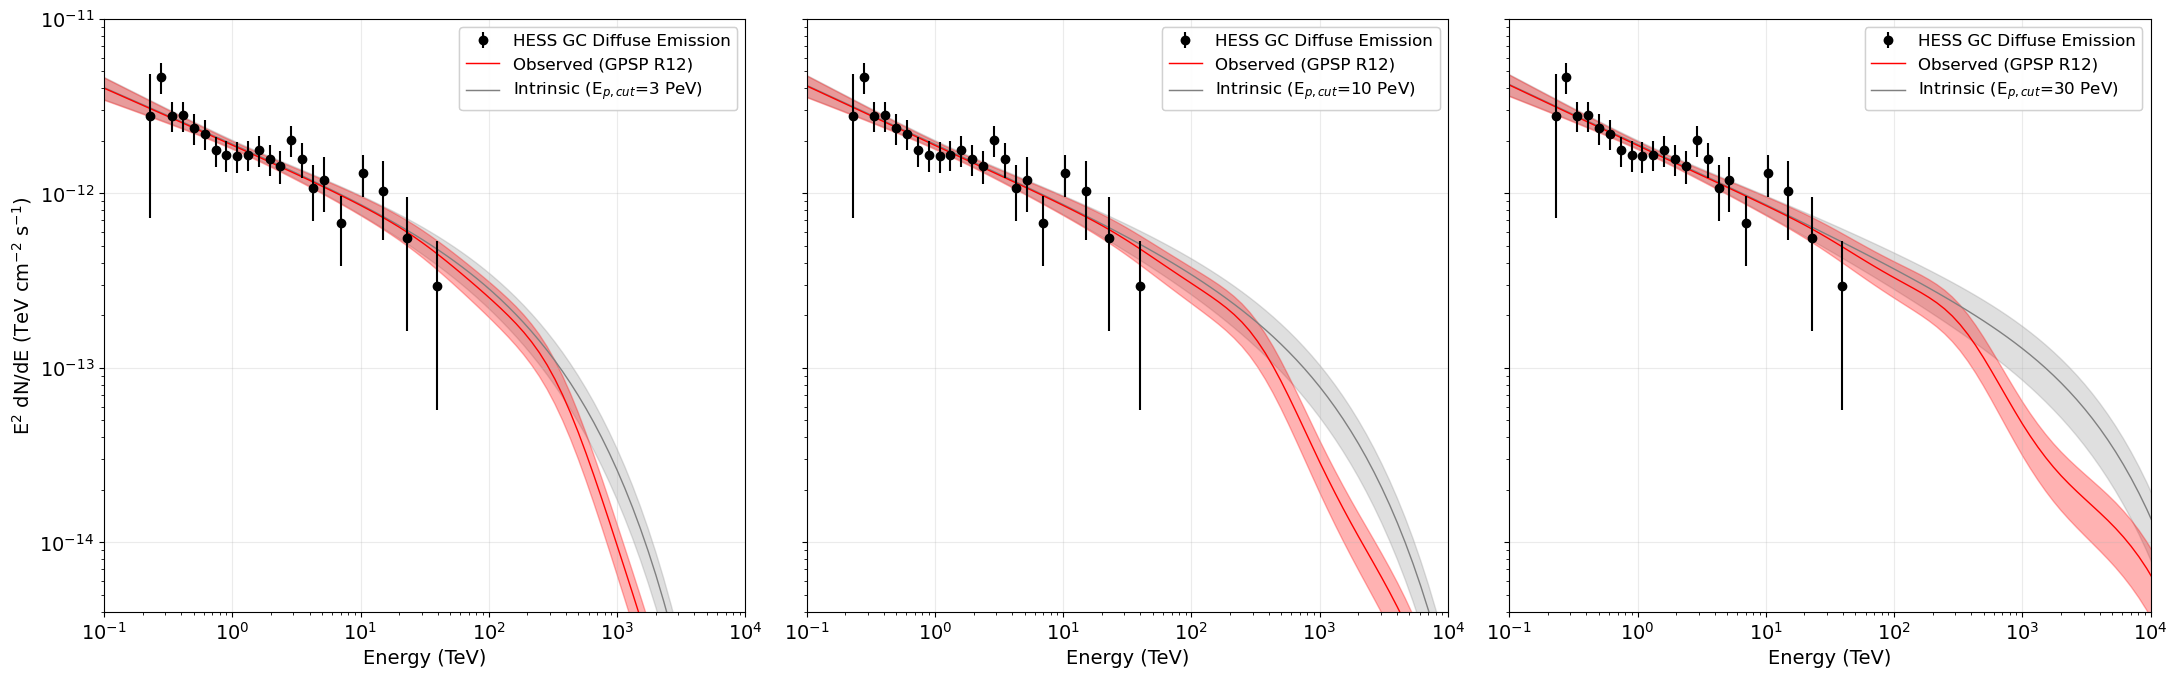

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)

for i, (ax, model) in enumerate(zip(axes, models)):
    cutoff = model["cutoff"]
    pp_model_file = model["file"]

    # Read & Process Spectra
    spec_table = QTable.read(pp_model_file, format="ascii.ecsv")
    energy = spec_table["e_ref"]

    sed_intrinsic = (energy**2 * spec_table["dnde"]).to("TeV cm-2 s-1")
    sed_intrinsic_err = (energy**2 * spec_table["dnde_err"]).to("TeV cm-2 s-1")

    # We apply survival profiles to the models to get the attenuated spectra. Errors are returned in linear combination.
    apply_result_r12 = atlas_r12.process_spectrum_with_gpsp(ecsv_file=pp_model_file, gpsp_result=result_r12, mode="apply", 
                                                            calc_errors=True, return_table=True, error_comb_mode='linear')
    
    sed_obs_r12 = (energy**2 * apply_result_r12["flux"]).to("TeV cm-2 s-1")
    sed_obs_err_r12 = (energy**2 * apply_result_r12.get("flux_err", np.zeros_like(sed_obs_r12))).to("TeV cm-2 s-1")

    # Plots
    label_int = f'Intrinsic (E$_{{p, cut}}$={cutoff} PeV)'
    p1, = ax.plot(energy, sed_intrinsic, lw=1, color='gray', label=label_int)
    ax.fill_between(energy.value, (sed_intrinsic - sed_intrinsic_err).value, (sed_intrinsic + sed_intrinsic_err).value, alpha=0.25, 
                    color='gray')

    p2, = ax.plot(energy, sed_obs_r12, lw=1, color='red', label='Observed (GPSP R12)')
    ax.fill_between(energy.value, (sed_obs_r12 - sed_obs_err_r12).value, (sed_obs_r12 + sed_obs_err_r12).value, alpha=0.30, color='red')

    p3 = ax.errorbar(hess_energy, hess_sed, yerr=hess_sed_err, color='black', marker='o', linestyle='None', 
                       label='HESS GC Diffuse Emission')

    # Create Split Legends
    leg1 = ax.legend(handles=[p3, p2, p1], loc='upper right', frameon=True)
    ax.add_artist(leg1)
    
    # Axis & Styling Cleanup
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Energy (TeV)")
    ax.tick_params(axis='both', which='major')
    ax.tick_params(axis='both', which='minor')
    
    if i == 0:
        ax.set_ylabel("E$^{2}$ dN/dE (TeV cm$^{-2}$ s$^{-1}$)")
    else:
        ax.set_ylabel("")
        ax.yaxis.set_tick_params(labelleft=False)

    ax.set_xlim(0.1, 10000)
    ax.set_ylim(4e-15, 1e-11)
    ax.grid(alpha=0.25)
    
plt.tight_layout()
plt.show()

## Interpretation

The figure compares intrinsic hadronic emission gamma-ray models with the corresponding attenuated spectra predicted by the GPSP atlas.

Several proton cutoff energies are shown in order to illustrate how Galactic $\gamma\gamma$ absorption affects the UHE region of the spectrum.

The difference between the intrinsic and attenuated spectra becomes increasingly pronounced as the intrinsic model extends deeper into the PeV regime.

This example demonstrates how the GPSP atlas can be incorporated directly into spectral modeling workflows to obtain predictions for observed Galactic gamma-ray spectra while consistently propagating morphology and distance uncertainties.